In [1]:
!pip install numpy pandas matplotlib seaborn networkx scipy tqdm

In [2]:
import os
import time
from abc import ABC, abstractmethod
from itertools import product
from typing import Callable, List, Optional, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.io import mmread
from tqdm import tqdm

## Frank-Wolfe Algorithm
The Frank-Wolfe algorithm, also known as the Conditional Gradient Method, is an iterative optimization technique designed for constrained convex optimization problems. It works by iteratively solving linear approximations of the objective function over the feasible set.

### Step Size Strategies

The Frank-Wolfe algorithm supports several step size determination strategies:

1. **Armijo Line Search**: A backtracking line search that ensures sufficient decrease in the objective. It starts with a large step size and reduces it until a sufficient decrease condition is met. (*Section 4 FW_survey.pdf*)

2. **Diminishing Step Size**: Uses a predefined schedule $\gamma_k = \frac{2}{k+2}$, which guarantees convergence while avoiding costly line searches. (*Algorithm 1 FW.pdf*, *Section 4 FW_survey.pdf*)

3. **Exact Line Search**: Finds the optimal step size by solving $\gamma_k = \arg\min_{\gamma \in [0,1]} f((1-\gamma)x_k + \gamma s_k)$. This provides the best progress per iteration but requires solving a one-dimensional optimization problem. (*Algorithm 3 FW.pdf* and *Section 4 FW_survey.pdf*)

4. **Exact Line Search for Away and Pairwise Variants**: For away-step and pairwise variants, the exact line search is modified to: $\gamma_k = \arg\min_{\gamma \in [0,\gamma_{max}]} f(x_k + \gamma d_k)$, where $\gamma_{max}$ may be restricted to less than 1 for away steps to ensure feasibility. (*Algorithm 1 FW_variants.pdf*)

In [ ]:
class FrankWolfeBase(ABC):
    """Abstract base class for Frank-Wolfe algorithm variants"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact', gamma: float = 0.1, delta: float = 0.5, exact_line_search: Optional[Callable] = None) -> None:
        self.max_iter = max_iter
        self.tol = tol
        self.line_search_strategy = line_search_strategy

        # Armijo rule parameters
        self.gamma = gamma  # sufficient decrease constant
        self.delta = delta  # step size reduction factor

        # Exact line search function
        self.exact_line_search = exact_line_search

        self.x_pred: Optional[np.ndarray] = None
        self.iter: int = 0
        self.loss_history: List[float] = []
        self.cpu_time_history: List[float] = []
        self.gap_history: List[float] = []

    @abstractmethod
    def fit(self, objective_function: Callable[[np.ndarray], float],
            compute_gradient: Callable[[np.ndarray], np.ndarray],
            lmo: Callable[[np.ndarray], np.ndarray],
            x0: np.ndarray) -> np.ndarray:
        """Solve the optimization problem starting from x0"""
        pass

    def _line_search(self, objective_function: Callable[[np.ndarray], float],
                     x: np.ndarray, k: int, d: np.ndarray,
                     grad: np.ndarray, max_step_size: float = 1.0) -> float:
        """Line search to find the optimal step size"""
        step_size = max_step_size

        if self.line_search_strategy == 'armijo':
            step_size = max_step_size

            f_x = objective_function(x)

            ref = self.gamma * (grad @ d)

            while True:
                x_new = x + step_size * d
                f_x_new = objective_function(x_new)

                if f_x_new <= f_x + step_size * ref:
                    break
                else:
                    step_size *= self.delta

                # Fixed step size if step size becomes too small
                if step_size <= 1e-10:
                    step_size = max_step_size
                    break

        elif self.line_search_strategy == 'diminishing':
            step_size = min(2 / (k + 2), max_step_size)

        elif self.line_search_strategy == 'exact':
            if self.exact_line_search is None:
                raise NotImplementedError('Exact line search needs to be implemented')

            _step_size = self.exact_line_search(objective_function, x, d, grad)
            step_size = min(_step_size, max_step_size)

        else:
            raise ValueError('Invalid line search strategy')

        return step_size

### Frank Wolfe

*Algorithm 1 FW.pdf*

1. Start with an initial feasible point $x_0$
2. At each iteration $k$:
    - Compute the gradient $\nabla f(x_k)$
    - Find the point $s$ in the feasible set that minimizes $\langle s, \nabla f(x_k) \rangle$
    - Determine the step size $\gamma_k$
    - Update: $x_{k+1} = (1-\gamma_k)x_k + \gamma_k s$

In [ ]:
class FrankWolfe(FrankWolfeBase):
    """Standard Frank-Wolfe algorithm implementation"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact', gamma: float = 0.1, delta: float = 0.5, exact_line_search: Optional[Callable] = None) -> None:
        super().__init__(max_iter, tol, line_search_strategy, gamma, delta, exact_line_search)

    def fit(self, objective_function: Callable[[np.ndarray], float],
            compute_gradient: Callable[[np.ndarray], np.ndarray],
            lmo: Callable[[np.ndarray], np.ndarray],
            x0: np.ndarray) -> np.ndarray:
        """Solve the optimization problem using standard Frank-Wolfe"""
        start_time = time.time()

        x = x0.copy()

        # Reset history
        self.loss_history = [objective_function(x)]
        self.cpu_time_history = [0.0]
        self.gap_history = []

        for k in range(self.max_iter):
            grad = compute_gradient(x)

            # Compute FW direction
            s = lmo(grad)

            gap = -grad @ (s - x)

            # Check convergence
            if gap < self.tol:
                break

            # Direction and step size
            d = s - x
            step_size = self._line_search(objective_function, x, k, d, grad)

            # Update solution
            x = x + step_size * d

            # Update history
            self.iter = k + 1
            self.gap_history.append(gap)
            self.loss_history.append(objective_function(x))
            self.cpu_time_history.append(time.time() - start_time)

        # Save the final solution
        self.x_pred = x.copy()

        return x

### Away Step Frank-Wolfe

*Algorithm 1 FW_variants.pdf*

1. Start with an initial feasible point $x_0$ and initialize active set $S_0 = {x_0}$
2. At each iteration $k$:
    - Compute the gradient $\nabla f(x_k)$
    - Find the Frank-Wolfe direction: Find $s_k$ in the feasible set that minimizes $\langle s_k, \nabla f(x_k) \rangle$, set $d^{fw} = s_k - x_k$
    - Find the Away direction: Find $v_k$ in the active set $S_k$ that maximizes $\langle v_k, \nabla f(x_k) \rangle$, set $d^{away} = x_k - v_k$
    - Compute the Frank-Wolfe gap $g^{fw} = \langle -\nabla f(x_k), d^{fw} \rangle$
    - If $g^{fw} \leq \varepsilon$, terminate (convergence)
    - Choose the direction with greater potential decrease:
      - If $\langle -\nabla f(x_k), d^{fw} \rangle \geq \langle -\nabla f(x_k), d^{away} \rangle$:
         - Use $d_k = d^{fw}$ (Frank-Wolfe direction)
         - Set $\gamma_{max} = 1$
      - Else:
         - Use $d_k = d^{away}$ (Away direction)
         - Set $\gamma_{max} = \frac{\alpha_{v_k}}{1-\alpha_{v_k}}$ (maximum feasible step size)
    - Determine the step size $\gamma_k$ through line search in $[0, \gamma_{max}]$
    - Update: $x_{k+1} = x_k + \gamma_k d_k$
    - Update the active set $S_{k+1}$

In [ ]:
class AwayStepFrankWolfe(FrankWolfeBase):
    """Away Step Frank-Wolfe algorithm implementation"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact', gamma: float = 0.1, delta: float = 0.5, exact_line_search: Optional[Callable] = None) -> None:
        super().__init__(max_iter, tol, line_search_strategy, gamma, delta, exact_line_search)

        self.active_set: List[Tuple[np.ndarray, float]] = None

    def _update_active_set(self, s: np.ndarray, a_idx: int, step_size: float, 
                          max_step_size: float, is_away: bool) -> List[Tuple[np.ndarray, float]]:
        """Update the active set

        For Frank-Wolfe steps:
        - If step_size = 1.0: Active set becomes just {s}
        - Otherwise: Add s to active set (if not already present)
        - Update weights:
          - For s: α_s = (1-step_size)*α_s + step_size
          - For other vertices v: α_v = (1-step_size)*α_v

        For Away steps:
        - If step_size = max_step_size: "Drop step" - remove away vertex completely
        - Otherwise: Keep away vertex with reduced weight
        - Update weights:
            - For away vertex: α_away = (1+step_size)*α_away - step_size
            - For other vertices v: α_v = (1+step_size)*α_v
        """
        new_active_set = []
        is_s_in_active_set = False

        # Away step case
        if is_away:
            is_drop_step = np.isclose(step_size, max_step_size)

            if is_drop_step:
                # Remove away vertex
                for v_idx, (vertex, weight) in enumerate(self.active_set):
                    if v_idx != a_idx:
                        # Rescale weights of remaining vertices
                        new_weight = weight / (1 - self.active_set[a_idx][1])
                        if new_weight > 1e-10:  # Numerical stability check
                            new_active_set.append((vertex, new_weight))
            else:
                # Update weights
                for v_idx, (vertex, weight) in enumerate(self.active_set):
                    if v_idx == a_idx:
                        # For away vertex: α_away = (1+step_size)*α_away - step_size
                        new_weight = (1 + step_size) * weight - step_size
                        if new_weight > 1e-10:  # Numerical stability check
                            new_active_set.append((vertex, new_weight))
                    else:
                        # For other vertices: α_v = (1+step_size)*α_v
                        new_active_set.append((vertex, (1 + step_size) * weight))
        # FW step case
        else:
            if np.isclose(step_size, 1.0):
                # Active set becomes just {s}
                new_active_set = [(s, 1.0)]
            else:
                for vertex, weight in self.active_set:
                    # For all vertices: α_v = (1-step_size)*α_v
                    new_weight = (1 - step_size) * weight

                    if np.array_equal(vertex, s):
                        # For s: α_s = (1-step_size)*α_s + step_size
                        new_weight += step_size
                        is_s_in_active_set = True

                    if new_weight > 1e-10:  # Numerical stability check
                        new_active_set.append((vertex, new_weight))

                # Add s to active set if not already present
                if not is_s_in_active_set:
                    new_active_set.append((s, step_size))

        return new_active_set

    def _compute_away_direction(self, grad: np.ndarray) -> Tuple[np.ndarray, int]:
        """Find the vertex in the active set with maximum inner product with gradient

        Need to maximize: max ⟨-∇f(x), x - v_t⟩

        ⟨-∇f(x), x - v_t⟩ = ⟨-∇f(x), x⟩ - ⟨-∇f(x), v_t⟩ = -⟨∇f(x), x⟩ + ⟨∇f(x), v_t⟩

        -⟨∇f(x), x⟩ is constant with respect to v_t, rewrite as: max ⟨∇f(x), v_t⟩
        """
        max_inner_product = -float('inf')
        away_vertex = None
        away_idx = None

        for i, (atom, weight) in enumerate(self.active_set):
            inner_product = grad @ atom
            if inner_product > max_inner_product:
                max_inner_product = inner_product
                away_vertex = atom
                away_idx = i

        return away_vertex, away_idx

    def fit(self, objective_function: Callable[[np.ndarray], float], 
            compute_gradient: Callable[[np.ndarray], np.ndarray], 
            lmo: Callable[[np.ndarray], np.ndarray], 
            x0: np.ndarray) -> np.ndarray:
        """Solve the optimization problem using Away Step Frank-Wolfe"""
        start_time = time.time()

        x = x0.copy()

        # Initialize active set: S(0) := {x(0)} with α(0)_x(0) = 1
        self.active_set = [(x0, 1.0)]

        # Reset history
        self.loss_history = [objective_function(x)]
        self.cpu_time_history = [0.0]
        self.gap_history = []

        for k in range(self.max_iter):
            grad = compute_gradient(x)

            # Compute FW direction
            s = lmo(grad)
            d_fw = s - x
            gap_fw = -(grad @ d_fw)

            # Check convergence
            if gap_fw < self.tol:
                break

            # Compute away direction
            a, a_idx = self._compute_away_direction(grad)
            d_away = x - a
            gap_away = -(grad @ d_away)

            # Choose direction
            is_away = gap_away > gap_fw
            if is_away:
                d = d_away
                away_weight = self.active_set[a_idx][1]
                max_step_size = away_weight / (1.0 - away_weight)
            else:
                d = d_fw
                max_step_size = 1.0

            # Step size
            step_size = self._line_search(objective_function, x, k, d, grad, max_step_size)

            # Update solution
            x = x + step_size * d

            # Update active set
            self.active_set = self._update_active_set(s, a_idx, step_size, max_step_size, is_away)

            # Update history
            self.iter = k + 1
            self.gap_history.append(gap_away if is_away else gap_fw)
            self.loss_history.append(objective_function(x))
            self.cpu_time_history.append(time.time() - start_time)

        # Save the final solution
        self.x_pred = x.copy()

        return x

### Pairwise Frank-Wolfe

*Algorithm 2 FW_variants.pdf*

1. Start with an initial feasible point $x_0$ and initialize active set $S_0 = {x_0}$
2. At each iteration $k$:
    - Compute the gradient $\nabla f(x_k)$
    - Find the Frank-Wolfe direction: Find $s_k$ in the feasible set that minimizes $\langle s_k, \nabla f(x_k) \rangle$, set $d^{fw} = s_k - x_k$
    - Find the Away direction: Find $v_k$ in the active set $S_k$ that maximizes $\langle v_k, \nabla f(x_k) \rangle$, set $d^{away} = x_k - v_k$
    - Compute the Frank-Wolfe gap $g^{fw} = \langle -\nabla f(x_k), d^{fw} \rangle$
    - If $g^{fw} \leq \varepsilon$, terminate (convergence)
    - Set the pairwise direction $d_k = s_k - v_k$
    - Set $\gamma_{max} = \alpha_{v_k}$ (the weight of away vertex $v_k$ in the active set)
    - Determine the step size $\gamma_k$ through line search in $[0, \gamma_{max}]$
    - Update: $x_{k+1} = x_k + \gamma_k d_k$
    - Update the active set $S_{k+1}$

In [ ]:
class PairwiseFrankWolfe(AwayStepFrankWolfe):
    """Pairwise Frank-Wolfe algorithm implementation"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact', gamma: float = 0.1, delta: float = 0.5, exact_line_search: Optional[Callable] = None) -> None:
        super().__init__(max_iter, tol, line_search_strategy, gamma, delta, exact_line_search)

    def _update_active_set(self, s: np.ndarray, a_idx: int, step_size: float, max_step_size: float) -> List[Tuple[np.ndarray, float]]:
        """Update the active set

        For Pairwise steps:
        - Away vertex (v_a):
          - If step_size = γ_max: "Drop step" - remove away vertex completely
          - Otherwise: α_a = α_a - γ
        - FW vertex (s):
          - If already in active set: α_s = α_s + γ
          - If not in active set: Add to active set with weight α_s = γ
        - Other vertices:
          - Weights remain unchanged
        """
        new_active_set = []
        is_drop_step = np.isclose(step_size, max_step_size)
        is_s_in_active_set = False

        for v_idx, (vertex, weight) in enumerate(self.active_set):
            if v_idx == a_idx:
                # Away vertex case
                if is_drop_step:
                    # Drop step: remove away vertex completely when γ = γ_max
                    continue
                else:
                    # For away vertex v_a: α_v_a = α_v_a - γ
                    new_weight = weight - step_size
                    if new_weight > 1e-10:  # Numerical stability check
                        new_active_set.append((vertex, new_weight))
            elif np.array_equal(vertex, s):
                # For FW vertex s: α_s = α_s + γ
                new_weight = weight + step_size
                new_active_set.append((vertex, new_weight))
                is_s_in_active_set = True
            else:
                # For other vertices v: α_v remains unchanged
                new_active_set.append((vertex, weight))

        if not is_s_in_active_set:
            new_active_set.append((s, step_size))

        return new_active_set

    def fit(self, objective_function: Callable[[np.ndarray], float], 
            compute_gradient: Callable[[np.ndarray], np.ndarray], 
            lmo: Callable[[np.ndarray], np.ndarray], 
            x0: np.ndarray) -> np.ndarray:
        """Solve optimization problem using Pairwise Frank-Wolfe"""
        start_time = time.time()

        x = x0.copy()

        # Initialize active set: S(0) := {x(0)} with α(0)_x(0) = 1
        self.active_set = [(x0, 1.0)]

        # Reset history
        self.loss_history = [objective_function(x)]
        self.cpu_time_history = [0.0]
        self.gap_history = []

        for k in range(self.max_iter):
            grad = compute_gradient(x)

            # Compute FW direction
            s = lmo(grad)
            d_fw = s - x
            gap_fw = -(grad @ d_fw)

            # Check convergence using the standard FW gap
            if gap_fw < self.tol:
                break

            # Compute away direction
            a, a_idx = self._compute_away_direction(grad)

            # Compute direction
            d = s - a
            max_step_size = self.active_set[a_idx][1]

            gap = -(grad @ d)

            # Step size
            step_size = self._line_search(objective_function, x, k, d, grad, max_step_size)

            # Update solution
            x = x + step_size * d

            # Update active set
            self.active_set = self._update_active_set(s, a_idx, step_size, max_step_size)

            # Update history
            self.iter = k + 1
            self.gap_history.append(gap)
            self.loss_history.append(objective_function(x))
            self.cpu_time_history.append(time.time() - start_time)

        # Save the final solution
        self.x_pred = x.copy()

        return x

## Algorithm performance visualization

In [7]:
def plot_metrics(solver: FrankWolfeBase, figsize: Tuple[int, int] = (14, 4), title: Optional[str] = None) -> None:
    """Plot the loss, CPU time, and gap history of the solver"""
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    # Plot loss history over iterations
    axs[0].plot(solver.loss_history)
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Loss')
    axs[0].grid(True, alpha=0.3)

    # Plot gap history over iterations
    axs[1].plot(solver.gap_history)
    axs[1].set_xlabel('Iterations')
    axs[1].set_ylabel('Gap')
    axs[1].grid(True, alpha=0.3)

    # Plot CPU time history over iterations
    axs[2].plot(solver.cpu_time_history)
    axs[2].set_xlabel('Iterations')
    axs[2].set_ylabel('CPU Time (s)')
    axs[2].grid(True, alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()


def compare_solvers(solvers: List[FrankWolfeBase], labels: List[str], figsize: Tuple[int, int] = (14, 4)) -> None:
    """Compare multiple solvers on the same problem"""
    fig, axs = plt.subplots(1, 3, figsize=figsize)
    colors = sns.color_palette("husl", len(solvers))

    line_styles = ['solid', 'dashed', 'dotted', 'dashdot']

    # Loss plot over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[0].plot(solver.loss_history, label=label, color=colors[i], linestyle=line_styles[i % len(line_styles)])

    axs[0].set_title('Loss vs Iterations', fontsize=14)
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Loss')
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # Gap plot over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[1].plot(solver.gap_history, label=label, color=colors[i], linestyle=line_styles[i % len(line_styles)])
    
    axs[1].set_title('Gap vs Iterations', fontsize=14)
    axs[1].set_xlabel('Iterations')
    axs[1].set_ylabel('Gap')
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    # CPU time plot over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[2].plot(solver.cpu_time_history, label=label, color=colors[i], linestyle=line_styles[i % len(line_styles)])

    axs[2].set_title('CPU Time vs Iterations', fontsize=14)
    axs[2].set_xlabel('Iterations')
    axs[2].set_ylabel('CPU Time (s)')
    axs[2].grid(True, alpha=0.3)
    axs[2].legend()

    plt.tight_layout()
    plt.show()

## Test on Convex Quadratic Function

$$\min_{x \in \Delta_n} f(x) = \frac{1}{2}x^T Q x + b^T x$$
where:
- $Q = A^T A + I$ is a positive definite matrix (with $A$ randomly generated)
- $b$ is a random vector
- $\Delta_n$ is the unit simplex: ${x \in \mathbb{R}^n : x_i \geq 0, \sum_{i=1}^n x_i = 1}$

Gradient of the objective function: $$\nabla f(x) = Qx + b$$

In [8]:
def solve_quadratic_simplex(n: int, solver: FrankWolfeBase, x0: np.ndarray, random_seed: Optional[int] = None) -> FrankWolfeBase:
    """Solve a quadratic optimization problem over the unit simplex using the specified solver"""

    if random_seed is not None:
        np.random.seed(random_seed)

    # Positive definite matrix Q
    A = np.random.randn(n, n)
    Q = A.T @ A + np.eye(n)

    # Linear term b
    b = np.random.randn(n)

    def objective_function(x: np.ndarray) -> float:
        """Objective function: f(x) = (1/2) x^T Q x + b^T x"""
        return 0.5 * x.T @ Q @ x + b.T @ x

    def compute_gradient(x: np.ndarray) -> np.ndarray:
        """Gradient: ∇f(x) = Q x + b"""
        return Q @ x + b

    def lmo(grad: np.ndarray) -> np.ndarray:
        """
        LMO for the unit simplex
        Returns the vertex e_i of the simplex that minimizes <e_i, grad>
        """
        # Find the index of the minimum component of the gradient
        s = np.zeros(n)
        i = np.argmin(grad)
        s[i] = 1.0
        return s

    # Solving the optimization problem
    x_pred = solver.fit(objective_function, compute_gradient, lmo, x0)

    return solver


def initialize_x0(n: int, method: str = 'random', random_seed: Optional[int] = None) -> np.ndarray:
    """Initialize the starting point x0"""

    x0 = np.zeros(n)

    # Random point in the simplex
    if method == 'random':
        if random_seed is not None:
            np.random.seed(random_seed)
        x0 = np.random.rand(n)
        x0 = x0 / np.sum(x0)  # Normalize to ensure it lies in the simplex

    # Center of the simplex
    elif method == 'center':
        x0 = np.ones(n) / n

    else:
        raise ValueError('Invalid initialization method')

    return x0

Best parameters: gamma=0.1, delta=0.5
Final loss: -0.61234, Final gap: 0.00000, Iterations: 38


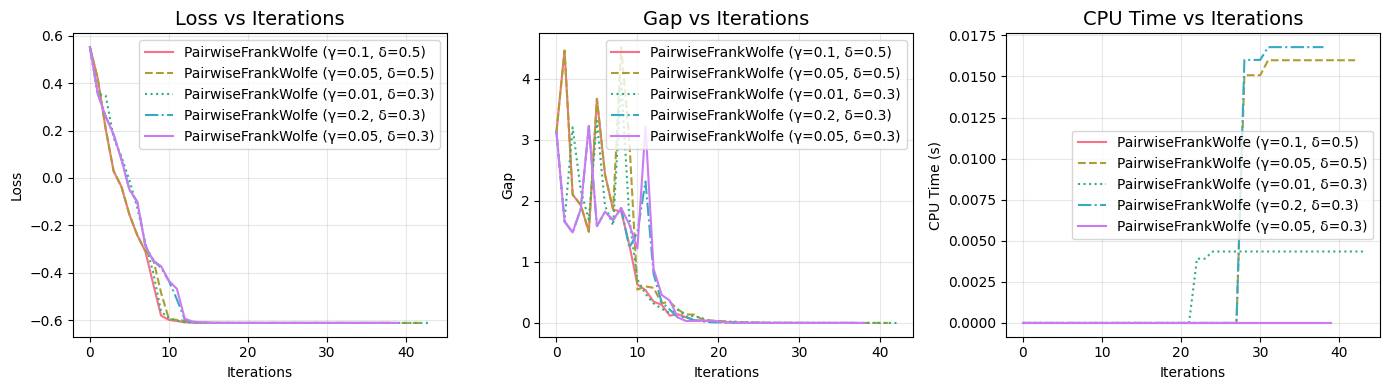

In [9]:
n = 10
max_iter = 50
tol = 1e-6
random_seed = 123
x0 = initialize_x0(n, 'center', random_seed)
solver_class = PairwiseFrankWolfe

gammas = [0.01, 0.05, 0.1, 0.2, 0.5]
deltas = [0.1, 0.3, 0.5, 0.7, 0.9]

results = []

# Test different Armijo parameter combinations
for gamma, delta in product(gammas, deltas):
    title = f"{solver_class.__name__} (γ={gamma}, δ={delta})"

    solver = solver_class(max_iter, tol, 'armijo', gamma, delta)
    fitted_solver = solve_quadratic_simplex(n, solver, x0, random_seed)

    results.append({
        'solver': fitted_solver,
        'final_loss': fitted_solver.loss_history[-1],
        'final_gap': fitted_solver.gap_history[-1],
        'label': title
    })

# The best parameter combination
best_result = min(results, key=lambda x: x['final_loss'])
print(f"Best parameters: gamma={best_result['solver'].gamma}, delta={best_result['solver'].delta}")
print(f"Final loss: {best_result['final_loss']:.5f}, Final gap: {best_result['final_gap']:.5f}, Iterations: {best_result['solver'].iter}")

# Compare top 5 results
top_results = sorted(results, key=lambda x: x['final_loss'])[:5]
compare_solvers(
    [r['solver'] for r in top_results],
    [r['label'] for r in top_results]
)

In [10]:
n = 10
max_iter = 1000
tol = 1e-6
random_seed = 123
x0 = initialize_x0(n, 'center', random_seed)

line_search_strats = [
    'armijo',
    'diminishing',
    # 'exact'       # Not implemented
]
armijo_params = {
    'gamma': 0.1,
    'delta': 0.5
}
solver_configs = [
    (FrankWolfe, "FW", {}),
    (AwayStepFrankWolfe, "Away Step FW", {}),
    (PairwiseFrankWolfe, "Pairwise FW", {})
]

solvers = {}

for solver_class, solver_name, solver_dict in solver_configs:
    for line_search in line_search_strats:
        title = f'{solver_name} ({line_search})'

        solver = solver_class(max_iter, tol, line_search, **armijo_params)
        fitted_solver = solve_quadratic_simplex(n, solver, x0, random_seed)
        solver_dict[title] = fitted_solver

        # plot_metrics(fitted_solver, title=title)

# Transfer to specific solver dict
fw_solvers = solver_configs[0][2]
fw_away_solvers = solver_configs[1][2]
fw_pw_solvers = solver_configs[2][2]

# Merge into a single dictionary
all_solvers = {
    **fw_solvers,
    **fw_away_solvers,
    **fw_pw_solvers
}

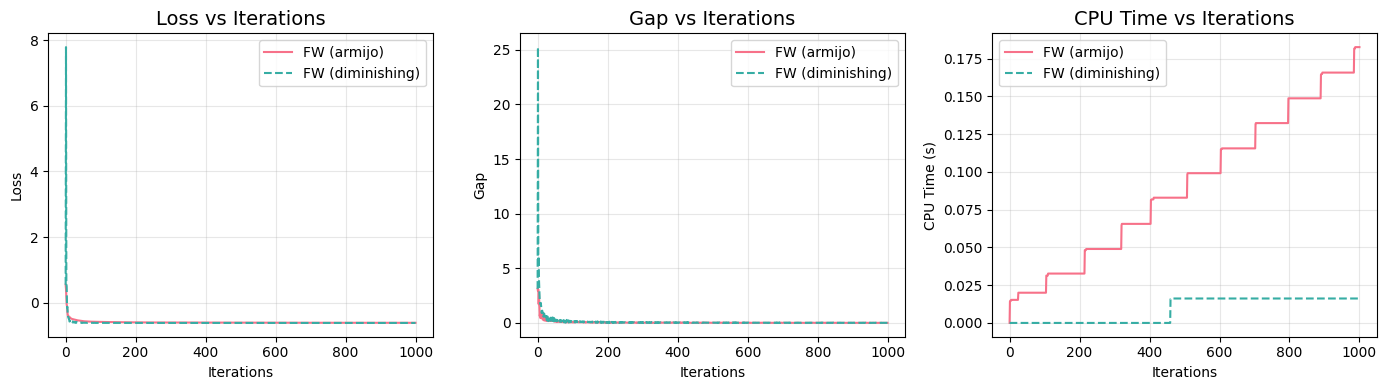

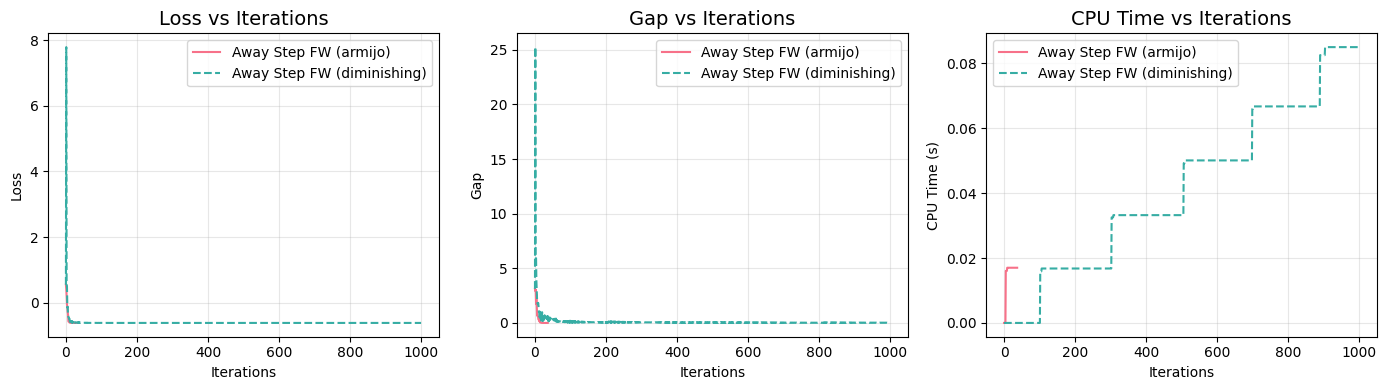

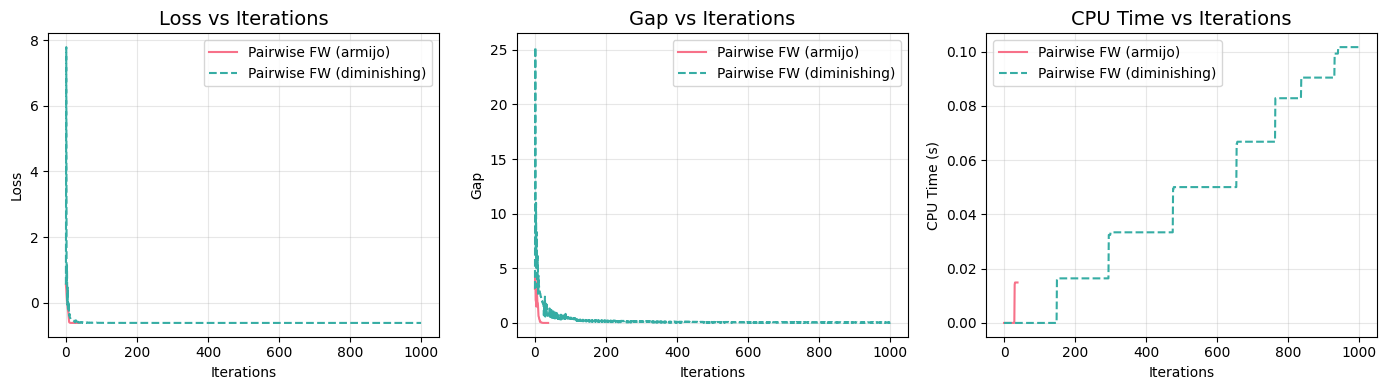

In [11]:
compare_solvers(list(fw_solvers.values()), list(fw_solvers.keys()))

compare_solvers(list(fw_away_solvers.values()), list(fw_away_solvers.keys()))

compare_solvers(list(fw_pw_solvers.values()), list(fw_pw_solvers.keys()))

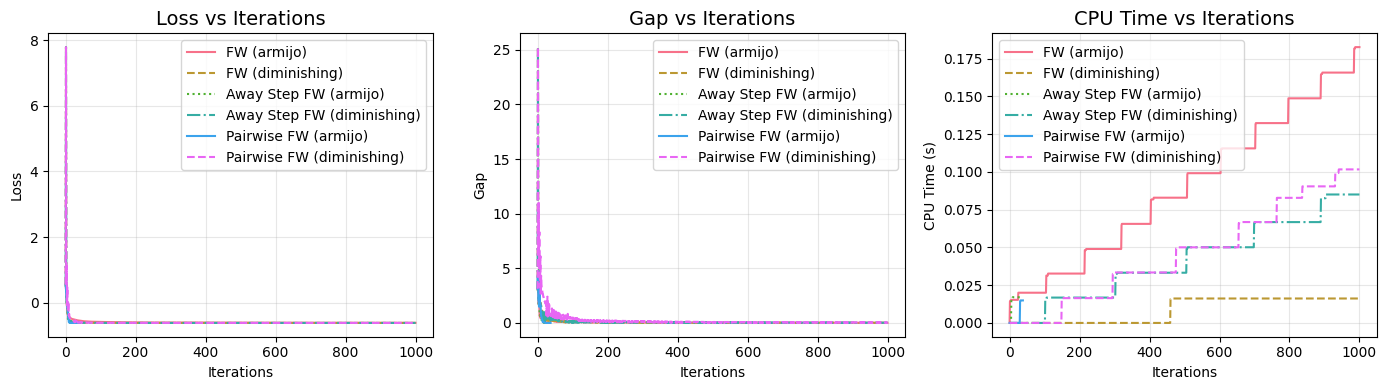

In [12]:
compare_solvers(list(all_solvers.values()), list(all_solvers.keys()))

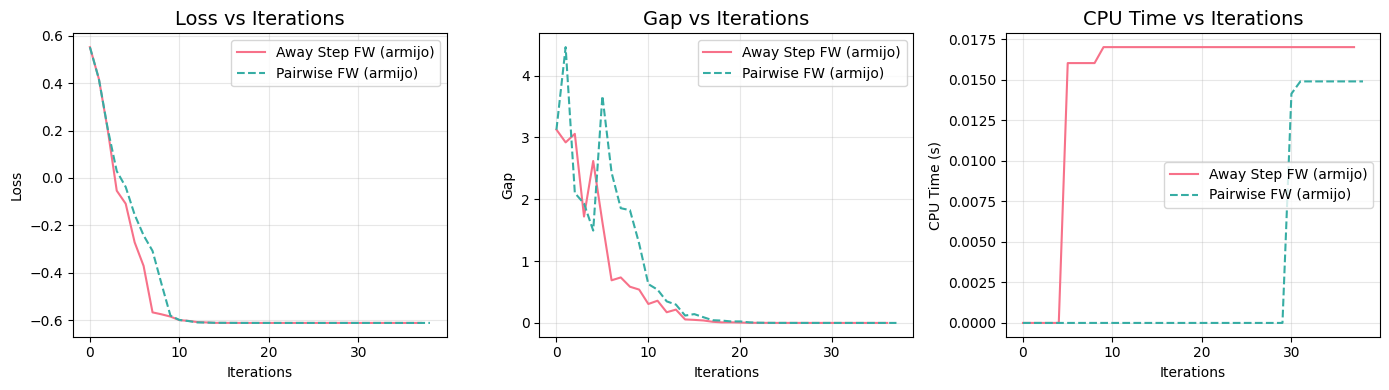

In [13]:
# Filter options (not applied if empty)
line_search_strats = [
    'armijo',
    # 'diminishing',
    # 'exact'
]
solver_classes = [
    # FrankWolfe,
    AwayStepFrankWolfe,
    PairwiseFrankWolfe
]

filtered_solvers = {}

# Check if the solver matches the filter criteria
for solver_name, solver in all_solvers.items():
    if (
        not line_search_strats or solver.line_search_strategy in line_search_strats
    ) and (
        not solver_classes or solver.__class__ in solver_classes
    ):
        filtered_solvers[solver_name] = solver

compare_solvers(
    list(filtered_solvers.values()),
    list(filtered_solvers.keys())
)

## Test on Max-Clique Problem

The Motzkin-Strauss formulation transforms the discrete max-clique problem into a continuous quadratic programming function: $$\max_{x \in \Delta} f(x) = x^T A x$$
where 
- $\Delta$ is the unit simplex and $A$ is the adjacency matrix of the graph.

Regularization is needed because of the spurious maximizer problem: $$\max_{x \in \Delta} f_{\Phi}(x) = x^T A x + \Phi(x)$$

We have 2 regularizers:
- $\Phi_B(x) = \frac{1}{2} |x|_2^2$
    - L2 regularization, discourages sparsity
    - Gradient: $\nabla\Phi_B(x) = x$
    - Exact step size: $\alpha_k=\frac{\nabla f_{\Phi}(x_k)^{\top}d_k}{2\,d_k^{\top}A\,d_k+d_k^{\top}d_k}$
- $\Phi_2(x) = \alpha \sum_{i=1}^n (e^{-\beta x_i} - 1)$
    - Smooth non-convex regularization approximating L0 sparsity, promotes sparse solutions
    - $\beta > 0, 0 < \alpha < \frac{2}{\beta^2}$
    - Gradient: $\nabla\Phi_2(x) = -\alpha \beta e^{-\beta x}$

To solve with minimization algorithms, we transform objective function to: $$\min_{x \in \Delta} -f(x) = -x^T A x - \Phi(x)$$
with gradient: $$\nabla(-f(x)) = -2Ax - \nabla\Phi(x)$$

In [14]:
def phi_l2(x):
    return 0.5 * x @ x


def grad_phi_l2(x):
    return x


def exact_line_search_l2():
    pass


def phi_l0(x, alpha=0.1, beta=10):
    return alpha * np.sum(np.exp(-beta * x) - 1)


def grad_phi_l0(x, alpha=0.1, beta=10):
    return -alpha * beta * np.exp(-beta * x)


def solve_max_clique(graph_adj: np.ndarray, solver: FrankWolfeBase, phi_func: Callable[[np.ndarray], float], grad_phi_func: Callable[[np.ndarray], np.ndarray], x0: np.ndarray) -> FrankWolfeBase:

    n = graph_adj.shape[0]
    A = graph_adj.astype(float)

    def get_regularized_objective_grad(A, phi, grad_phi) -> Tuple[Callable[[np.ndarray], float], Callable[[np.ndarray], np.ndarray]]:
        def objective(x):
            return -x.T @ A @ x - phi(x)

        def grad(x) -> np.ndarray:
            return -2 * A @ x - grad_phi(x)
        return objective, grad

    def lmo(grad: np.ndarray) -> np.ndarray:
        s = np.zeros(n)
        s[np.argmin(grad)] = 1.0
        return s

    objective_function, compute_gradient = get_regularized_objective_grad(
        A, phi_func, grad_phi_func
    )

    solver.fit(objective_function, compute_gradient, lmo, x0)

    return solver


def initialize_max_clique_x0(graph_adj: np.ndarray, method: str = 'random', random_seed: Optional[int] = None) -> np.ndarray:
    """Initialize the starting point x0"""

    n = graph_adj.shape[0]
    x0 = np.zeros(n)

    # Random point in the simplex
    if method == 'random':
        if random_seed is not None:
            np.random.seed(random_seed)
        x0 = np.random.rand(n)
        x0 = x0 / np.sum(x0)  # Normalize to ensure it lies in the simplex

    # Center of the simplex
    elif method == 'center':
        x0 = np.ones(n) / n

    # Degree weights proportional to the degree of each vertex
    elif method == 'degree_weighted':
        raise NotImplementedError('Degree weighted initialization is not implemented')

    else:
        raise ValueError('Invalid initialization method')

    return x0


def extract_clique_size(x_sol, threshold=1e-6):
    """
    Extract the number of vertices in the maximum clique from the solution.
    """
    # Find support of x_sol (indices where x_sol[i] > threshold)
    support = np.where(x_sol > threshold)[0]

    return len(support), support

### Triangle and isolated node

In [15]:
G = nx.Graph()
G.add_edges_from([(0, 1), (1, 2), (2, 0)])  # triangle
G.add_node(3)  # isolated node
adj_matrix = nx.to_numpy_array(G)

max_iter = 100
tol = 1e-6
random_seed = 123
x0 = initialize_max_clique_x0(adj_matrix, 'random', random_seed)

line_search_strats = [
    'armijo',
    'diminishing'
]
solver_configs = [
    (FrankWolfe, "FW", {}),
    (AwayStepFrankWolfe, "Away Step FW", {}),
    (PairwiseFrankWolfe, "Pairwise FW", {})
]
regularizers = [
    ('L2', phi_l2, grad_phi_l2),
    ('L0', phi_l0, grad_phi_l0)
]

for solver_class, solver_name, solver_dict in solver_configs:
    for line_search in line_search_strats:
        for reg_name, phi_func, grad_phi_func in regularizers:
            title = f'{solver_name} ({line_search} + {reg_name})'

            solver = solver_class(max_iter, tol, line_search)
            fitted_solver = solve_max_clique(adj_matrix, solver, phi_func, grad_phi_func, x0)
            solver_dict[title] = fitted_solver

            x_pred = fitted_solver.x_pred
            max_clique_size, max_clique_vertices = extract_clique_size(x_pred)

            print(f"Max clique size. {title}: {max_clique_size}")

            # plot_metrics(fitted_solver, title=title)
            # nx.draw(G, with_labels=True, node_color=x_pred, cmap='viridis')
            # plt.title(f"Node weights. {title}")
            # plt.show()

Max clique size. FW (armijo + L2): 3
Max clique size. FW (armijo + L0): 4
Max clique size. FW (diminishing + L2): 3
Max clique size. FW (diminishing + L0): 2
Max clique size. Away Step FW (armijo + L2): 3
Max clique size. Away Step FW (armijo + L0): 3
Max clique size. Away Step FW (diminishing + L2): 3
Max clique size. Away Step FW (diminishing + L0): 2
Max clique size. Pairwise FW (armijo + L2): 3
Max clique size. Pairwise FW (armijo + L0): 3
Max clique size. Pairwise FW (diminishing + L2): 3
Max clique size. Pairwise FW (diminishing + L0): 3


### DIMACS Instances

In [16]:
data_dir = './data/'

In [17]:
def list_graph_paths(data_dir=data_dir):
    """List all DIMACS graph files in the data directory"""
    graph_files = []
    for file in os.listdir(data_dir):
        if file.endswith('.mtx'):
            graph_files.append(os.path.join(data_dir, file))
    return graph_files


def load_graph(graph_path):
    """Load a graph from a .mtx file and return its name and adjacency matrix"""
    graph_name = os.path.basename(graph_path).split('.')[0]

    adj_matrix = mmread(graph_path).astype(float).todense()
    adj_matrix = np.array(adj_matrix)

    assert np.allclose(adj_matrix, adj_matrix.T), 'Matrix is not symmetric'

    # print(f'Size: {adj_matrix.shape[0]} nodes')

    return graph_name, adj_matrix

In [18]:
dimacs_graph_paths = list_graph_paths(data_dir)

print(f'Found {len(dimacs_graph_paths)} DIMACS graph files')

Found 31 DIMACS graph files


#### Hyperparameter Selection
- **Armijo Line Search Parameters**: *gamma (γ)*, *delta (δ)*
- **L0 Regularization Parameters**: *alpha (α)*, *beta (β)*

#### Experiments

In [19]:
def solve_dimacs_max_clique(graph_adj: np.ndarray, solver: FrankWolfeBase, phi_func: Callable[[np.ndarray], float], grad_phi_func: Callable[[np.ndarray], np.ndarray], x0: np.ndarray) -> FrankWolfeBase:
    """Solve the maximum clique problem for a given DIMACS instance (adjacency matrix) using the specified solver"""

    fitted_solver = solve_max_clique(
        graph_adj, solver, phi_func, grad_phi_func, x0
    )

    x_pred = fitted_solver.x_pred
    max_clique_size, max_clique_vertices = extract_clique_size(x_pred)

    return fitted_solver, max_clique_size


def run_dimacs_max_clique_experiments(graph_paths: List[str], solver: FrankWolfeBase, regularizers: List[Tuple[str, Callable, Callable]], num_trials: int = 100, random_seed: int = 123) -> Dict[str, Dict[str, List[float]]]:
    """Run experiments on DIMACS instances with the specified solver and regularizers"""

    results = {}

    for graph_path in graph_paths:
        graph_cpu_results = {}
        graph_mcp_results = {}

        graph_name, graph_adj = load_graph(graph_path)

        n = graph_adj.shape[0]

        print(f'\nProcessing graph: {graph_name} with {n} nodes')

        for reg_name, phi_func, grad_phi_func in regularizers:
            reg_cpu_results = []
            reg_mcp_results = []

            for trial in tqdm(range(num_trials), desc=f'Running with {reg_name}'):
                x0 = initialize_max_clique_x0(
                    graph_adj, 'random',
                    random_seed + trial
                )

                fitted_solver, max_clique_size = solve_dimacs_max_clique(
                    graph_adj, solver, phi_func, grad_phi_func, x0
                )

                cpu_time = fitted_solver.cpu_time_history[-1]

                reg_cpu_results.append(cpu_time)
                reg_mcp_results.append(max_clique_size)

            graph_cpu_results[reg_name] = reg_cpu_results
            graph_mcp_results[reg_name] = reg_mcp_results

        results[graph_name] = {
            'cpu_time': graph_cpu_results,
            'max_clique_size': graph_mcp_results
        }

    return results

In [20]:
def create_experiments_results_df(experiment_results: Dict[str, Dict[str, List[float]]], regularizers: List[str]) -> pd.DataFrame:
    """Create a DataFrame with results in the format:
    - Rows indexed by graph instances
    - Columns with multi-level structure for different regularizers
    - Statistics (max, mean, std, CPU time) for each regularizer"""

    levels = ['max', 'mean', 'std', 'CPU time']

    columns = pd.MultiIndex.from_product(
        [regularizers, levels],
        names=['Regularizer', 'Statistic']
    )

    df = pd.DataFrame(index=experiment_results.keys(), columns=columns)
    df.index.name = 'Instances'

    for graph_name, graph_results in experiment_results.items():
        for reg_name in regularizers:
            clique_sizes = graph_results['max_clique_size'][reg_name]
            cpu_times = graph_results['cpu_time'][reg_name]

            # Round clique sizes to integers
            clique_sizes = [int(round(size)) for size in clique_sizes]

            # Calculate statistics
            df.loc[graph_name, (reg_name, 'max')] = max(clique_sizes)
            df.loc[graph_name, (reg_name, 'mean')] = round(np.mean(clique_sizes), 2)
            df.loc[graph_name, (reg_name, 'std')] = round(np.std(clique_sizes), 2)
            df.loc[graph_name, (reg_name, 'CPU time')] = round(np.mean(cpu_times), 2)

    return df

In [21]:
max_iter = 1000
tol = 1e-6
random_seed = 123
line_search_strat = [
    'armijo',
    'diminishing'
]
armijo_params = {
    'gamma': 0.1,
    'delta': 0.5
}
regularization_params = {
    'alpha': 0.01,
    'beta': 5
}
regularizers = [
    ('L2', phi_l2, grad_phi_l2),
    ('L0', lambda x: phi_l0(x, **regularization_params), lambda x: grad_phi_l0(x, **regularization_params))
]
solver_configs = [
    (FrankWolfe, "FW", {}),
    (AwayStepFrankWolfe, "Away Step FW", {}),
    (PairwiseFrankWolfe, "Pairwise FW", {})
]

solvers = {}

# TODO: try different solvers with different combinations of line search strats

In [22]:
solver = PairwiseFrankWolfe(
    max_iter=max_iter, tol=tol,
    line_search_strategy='armijo',
    **armijo_params
)

experiment_results = run_dimacs_max_clique_experiments(
    dimacs_graph_paths[:5],
    solver,
    regularizers,
    num_trials=100,
    random_seed=random_seed
)

create_experiments_results_df(
    experiment_results,
    [reg_name for reg_name, _, _ in regularizers]
)


Processing graph: brock200-2 with 200 nodes


Running with L0: 100%|██████████| 100/100 [00:01<00:00, 57.79it/s]



Processing graph: brock200-4 with 200 nodes


Running with L0: 100%|██████████| 100/100 [00:03<00:00, 30.91it/s]



Processing graph: brock400-2 with 400 nodes


...


Processing graph: brock400-4 with 400 nodes


Running with L0: 100%|██████████| 100/100 [00:12<00:00,  8.10it/s]



Processing graph: brock800-2 with 800 nodes


Running with L0: 100%|██████████| 100/100 [00:40<00:00,  2.47it/s]


Regularizer  L2                        L0                      
Statistic   max   mean   std CPU time max   mean   std CPU time
Instances                                                      
brock200-2   10   7.57   0.9     0.01  10   7.76  0.75     0.02
brock200-4   14  12.01  1.13     0.02  15   11.9  1.14     0.03
brock400-2   20  17.52  1.26      0.1  21   18.4  1.21     0.12
brock400-4   21  17.39  1.41     0.09  21  18.03  1.27     0.12
brock800-2   16  14.41  1.01     0.31  17  14.74  1.04      0.4